### 한글 폰트 설정

그래프에서 한글이 올바르게 표시되도록 `나눔고딕(NanumGothic)` 폰트를 설치하고 Matplotlib에 설정합니다.

**주의:** 이 셀을 실행한 후에는 반드시 런타임을 다시 시작해야 폰트 변경이 완전히 적용됩니다. (메뉴: 런타임 > 런타임 다시 시작)

In [ ]:
# 나눔고딕 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# NanumGothic 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 0 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (3,962 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import drive
import matplotlib.font_manager as fm
import os

drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/교통문제공모전/commute_result_with_avg.csv'

commute_df = pd.read_csv(file_path, encoding='cp949')
commute_df.head(10)

# 한글 폰트 설정: NanumGothic 폰트를 직접 등록하고 rcParams에 설정
font_name = 'NanumGothic'
font_prop = None
font_found_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf' # 이전 실행 결과에서 찾은 경로

if os.path.exists(font_found_path):
    try:
        # Matplotlib의 fontManager에 폰트 직접 추가
        fm.fontManager.addfont(font_found_path)
        font_prop = fm.FontProperties(fname=font_found_path)

        # rcParams에 폰트 설정. NanumGothic을 우선순위에 두고 다른 sans-serif 폰트를 fallback으로 지정.
        plt.rcParams['font.family'] = ['NanumGothic', 'sans-serif']
        plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

        print(f"Font '{font_name}' successfully added and set for rcParams from path: {font_found_path}")
        print(f"Current font.family rcParam: {plt.rcParams['font.family']}")

    except Exception as e:
        print(f"Error during font registration or rcParams setting: {e}. Falling back to default Matplotlib font.")
        font_prop = None
else:
    print(f"Error: Font file not found at {font_found_path}. Please ensure 'fonts-nanum' is installed and runtime restarted.")
    print("Falling back to default Matplotlib font, Korean characters may not display.")

Mounted at /content/drive
Font 'NanumGothic' successfully added and set for rcParams from path: /usr/share/fonts/truetype/nanum/NanumGothic.ttf
Current font.family rcParam: ['NanumGothic', 'sans-serif']


**수도권 읍면동별 출근시간 오래 걸리는 상위 20개 지역**

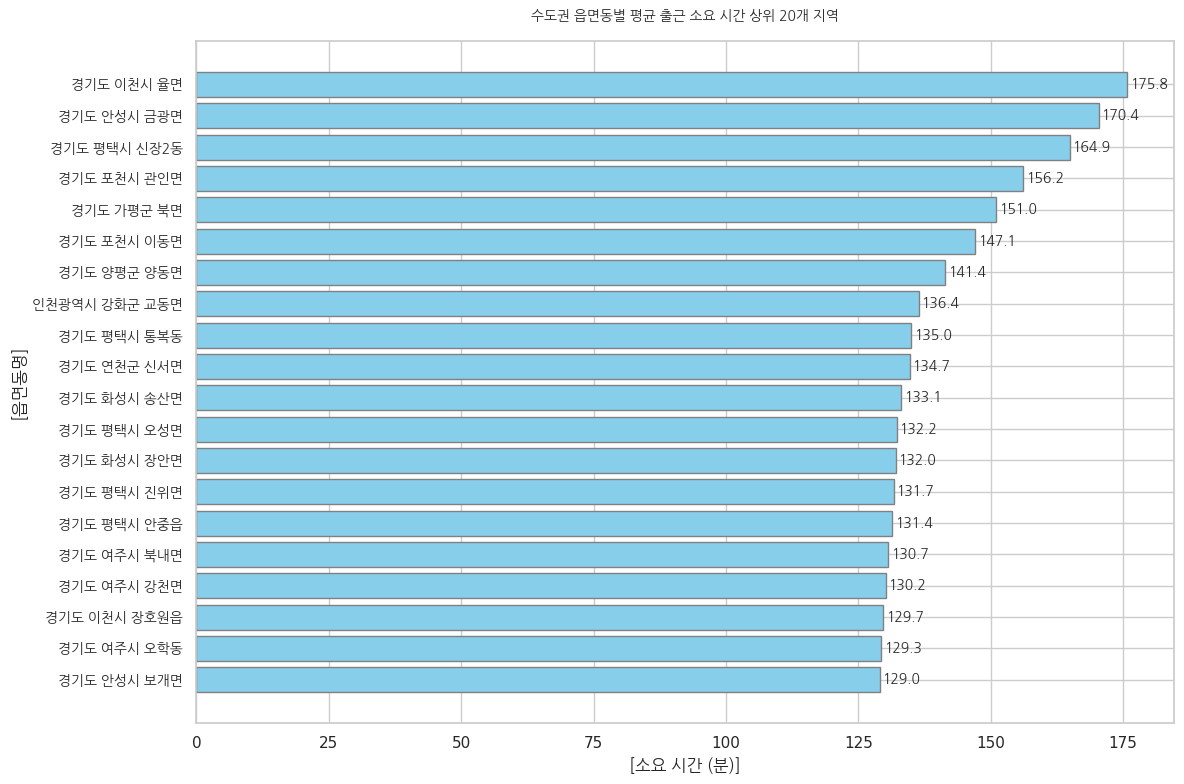

In [ ]:
# '행정동명' 컬럼의 불필요한 '\r' 문자 제거
commute_df['행정동명'] = commute_df['행정동명'].str.replace('\r', '', regex=False)

# 출퇴근 총 소요 시간(또는 평균) 계산 후 상위 20개 행정동 추출
df_top20 = commute_df.sort_values(by='평균 출근시간', ascending=False).head(20)

# 시각화 설정
plt.figure(figsize=(12, 8))
sns.set_theme(style='whitegrid')

# 가로 막대 그래프 그리기 (상위 20개가 위로 오도록 오름차순 정렬 후 출력)
df_sorted = df_top20.sort_values(by='평균 출근시간', ascending=True)

bars = plt.barh(
    df_sorted['행정동명'],
    df_sorted['평균 출근시간'],
    color='skyblue',
    edgecolor='grey',
)

# 그래프 제목 및 라벨 설정
# fontproperties가 정의된 경우에만 적용
plt.title(
    '수도권 읍면동별 평균 출근 소요 시간 상위 20개 지역',
    fontsize=20,
    fontweight='bold',
    pad=15,
    fontproperties=font_prop if font_prop else None
)
plt.xlabel('[소요 시간 (분)]', fontsize=12, fontproperties=font_prop if font_prop else None)
plt.ylabel('[읍면동명]', fontsize=12, fontproperties=font_prop if font_prop else None)

# 각 막대 옆에 수치 표시
for bar in bars:
  width = bar.get_width()
  plt.text(
      width + 0.5,
      bar.get_y() + bar.get_height() / 2,
      f'{width:.1f}',
      va='center',
      ha='left',
      fontsize=10,
      fontproperties=font_prop if font_prop else None
  )

# y축 틱 라벨에도 폰트 적용
if font_prop:
    for label in plt.gca().get_yticklabels():
        label.set_fontproperties(font_prop)

plt.tight_layout()
plt.savefig('수도권 읍면동별 평균 출근 소요 시간 상위 20개 지역.png', dpi=300, bbox_inches='tight')
plt.show()

**수도권 읍면동별 퇴근시간 오래 걸리는 상위 20개 지역**

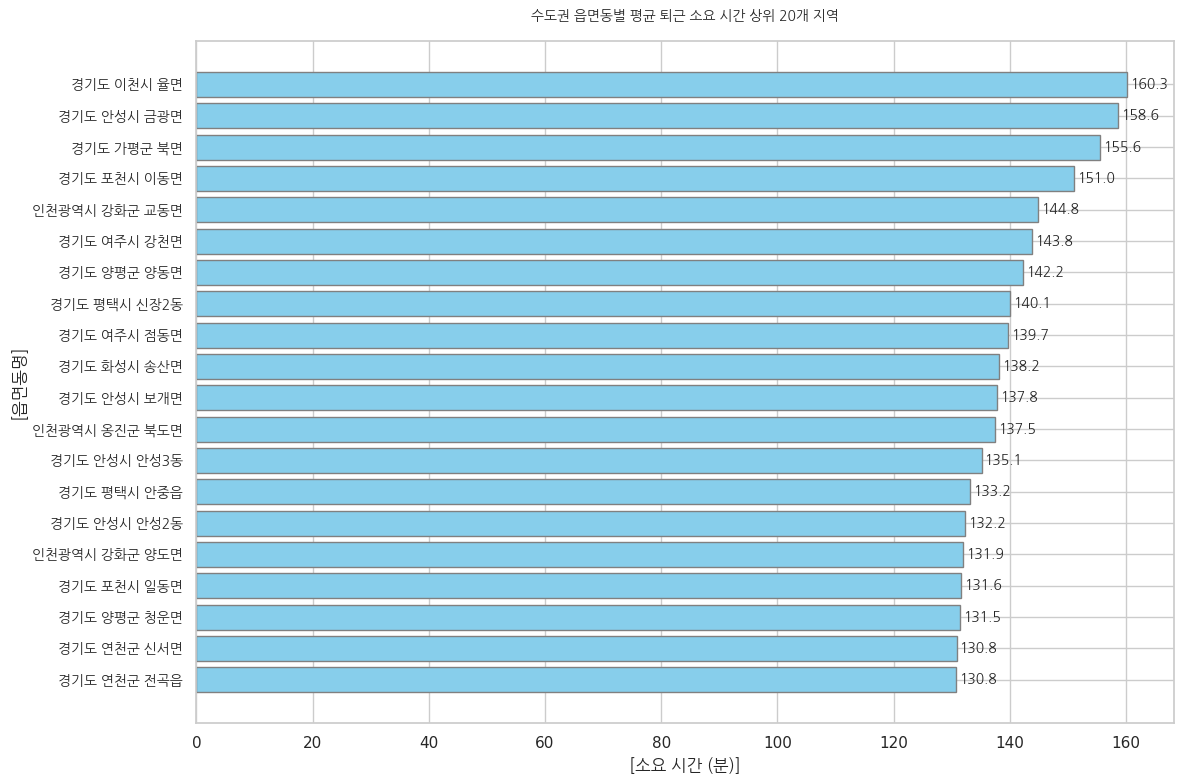

In [ ]:
# '행정동명' 컬럼의 불필요한 '\r' 문자 제거
commute_df['행정동명'] = commute_df['행정동명'].str.replace('\r', '', regex=False)

# 출퇴근 총 소요 시간(또는 평균) 계산 후 상위 20개 행정동 추출
df_top20 = commute_df.sort_values(by='평균 퇴근시간', ascending=False).head(20)

# 시각화 설정
plt.figure(figsize=(12, 8))
sns.set_theme(style='whitegrid')

# 가로 막대 그래프 그리기 (상위 20개가 위로 오도록 오름차순 정렬 후 출력)
df_sorted = df_top20.sort_values(by='평균 퇴근시간', ascending=True)

bars = plt.barh(
    df_sorted['행정동명'],
    df_sorted['평균 퇴근시간'],
    color='skyblue',
    edgecolor='grey',
)

# 그래프 제목 및 라벨 설정
# fontproperties가 정의된 경우에만 적용
plt.title(
    '수도권 읍면동별 평균 퇴근 소요 시간 상위 20개 지역',
    fontsize=20,
    fontweight='bold',
    pad=15,
    fontproperties=font_prop if font_prop else None
)
plt.xlabel('[소요 시간 (분)]', fontsize=12, fontproperties=font_prop if font_prop else None)
plt.ylabel('[읍면동명]', fontsize=12, fontproperties=font_prop if font_prop else None)

# 각 막대 옆에 수치 표시
for bar in bars:
  width = bar.get_width()
  plt.text(
      width + 0.5,
      bar.get_y() + bar.get_height() / 2,
      f'{width:.1f}',
      va='center',
      ha='left',
      fontsize=10,
      fontproperties=font_prop if font_prop else None
  )

# y축 틱 라벨에도 폰트 적용
if font_prop:
    for label in plt.gca().get_yticklabels():
        label.set_fontproperties(font_prop)

plt.tight_layout()
plt.savefig('수도권 읍면동별 평균 퇴근 소요 시간 상위 20개 지역.png', dpi=300, bbox_inches='tight')
plt.show()

**수도권 읍면동별 평균 출근시간 매핑**

병합된 GeoDataFrame (merged_gdf)의 행 개수: 1129


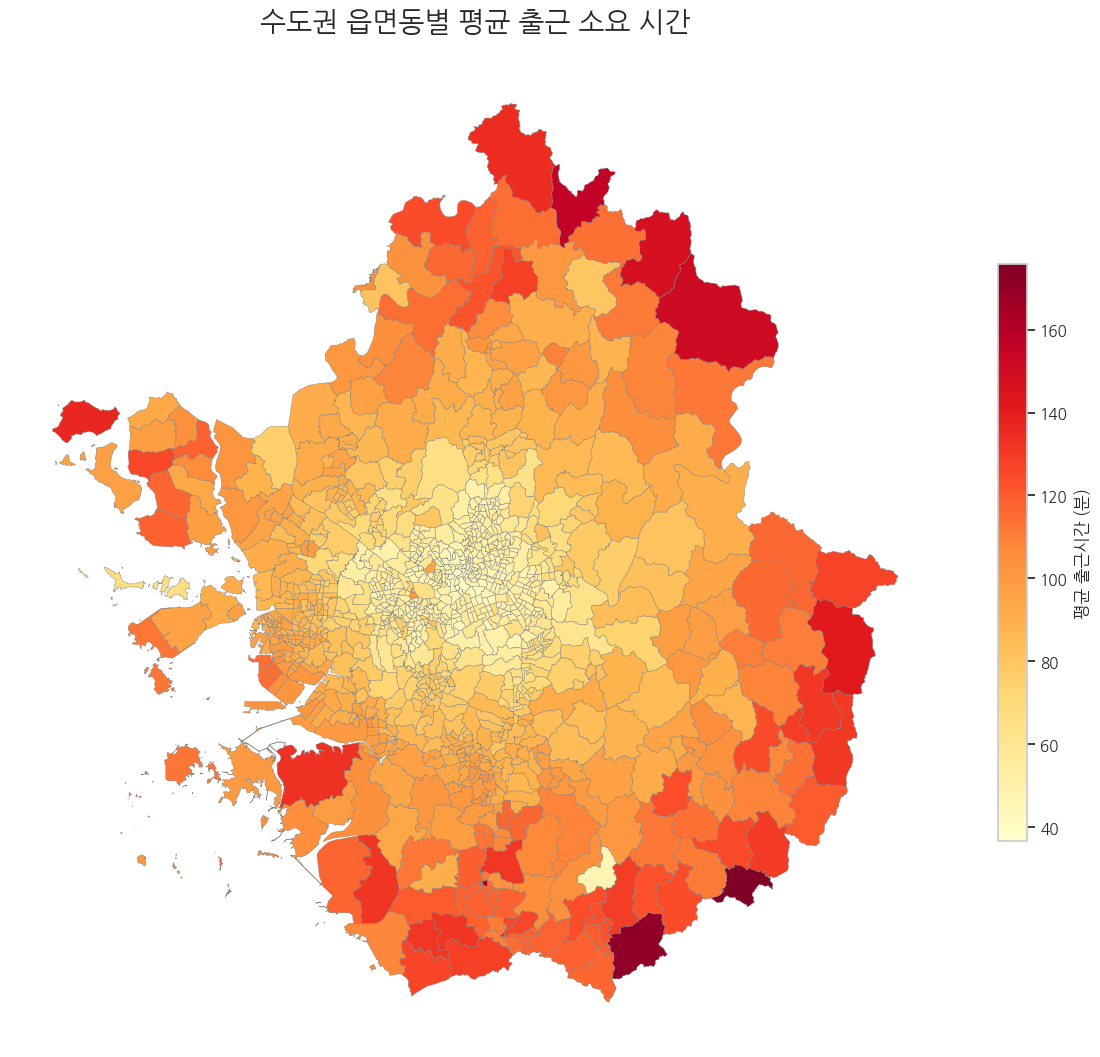

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Shapefile 지도 데이터 불러오기
shp_path = '/content/drive/MyDrive/교통문제공모전/updated_shapefile.shp'
gdf = gpd.read_file(shp_path, encoding='cp949')

# 2. 통근 결과 CSV 데이터 불러오기
commute_path = '/content/drive/MyDrive/교통문제공모전/commute_result_with_avg.csv'
df = pd.read_csv(commute_path, encoding='cp949')

# 'ADM_CD' 컬럼을 문자열로 변환
gdf['ADM_CD'] = gdf['ADM_CD'].astype(str)
# '행정동별 코드' 컬럼의 불필요한 '\r' 문자 제거 및 문자열 변환
# 그리고 gdf의 ADM_CD와 길이를 맞추기 위해 7자리 코드에 '0'을 추가 (예: '1101053' -> '11010530')
df['행정동별 코드'] = df['행정동별 코드'].astype(str).str.replace('\r', '', regex=False)

# 3. 수도권(서울, 인천, 경기) 데이터만 필터링하기 (11: 서울, 23: 인천, 31: 경기)
# 앞 2자리 코드를 추출하여 수도권만 남기기
gdf['sido_code'] = gdf['ADM_CD'].str[:2]
gdf_metro = gdf[gdf['sido_code'].isin(['11', '23', '31'])]

# 4. 지도 데이터(GeoDataFrame)와 통근 데이터(DataFrame) 병합
# 지도 데이터의 읍면동 코드와 CSV의 읍면동 코드를 기준으로 조인
merged_gdf = gdf_metro.merge(df, left_on='ADM_CD', right_on='행정동별 코드', how='inner')

print(f"병합된 GeoDataFrame (merged_gdf)의 행 개수: {len(merged_gdf)}")

# 5. 단계구분도(Choropleth Map) 그리기
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 도화지 크기 설정
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# 시각화 실행
merged_gdf.plot(
    column='평균 출근시간',         # 시각화할 통근 데이터의 수치 컬럼명 입력
    ax=ax,
    cmap='YlOrRd',                # 색상 지도 (Yellow-Orange-Red)
    legend=True,
    legend_kwds={'shrink': 0.5, 'label': "평균 출근시간 (분)"}, # 범례 설정
    edgecolor='gray',             # 읍면동 경계선 색상
    linewidth=0.3,                # 경계선 두께
    missing_kwds={'color': 'lightgrey',
                  "hatch": "////"} # 데이터가 없는 지역의 색상
)

plt.title('수도권 읍면동별 평균 출근 소요 시간', fontsize=20, fontweight='bold', pad=20)
ax.set_axis_off() # 지저분한 X, Y축 좌표선 숨기기

# 결과물 이미지로 저장
plt.savefig('수도권_읍면동별_출근시간_지도.png', dpi=300, bbox_inches='tight')
plt.show()

**수도권 읍면동별 평균 퇴근시간 매핑**

병합된 GeoDataFrame (merged_gdf)의 행 개수: 1129


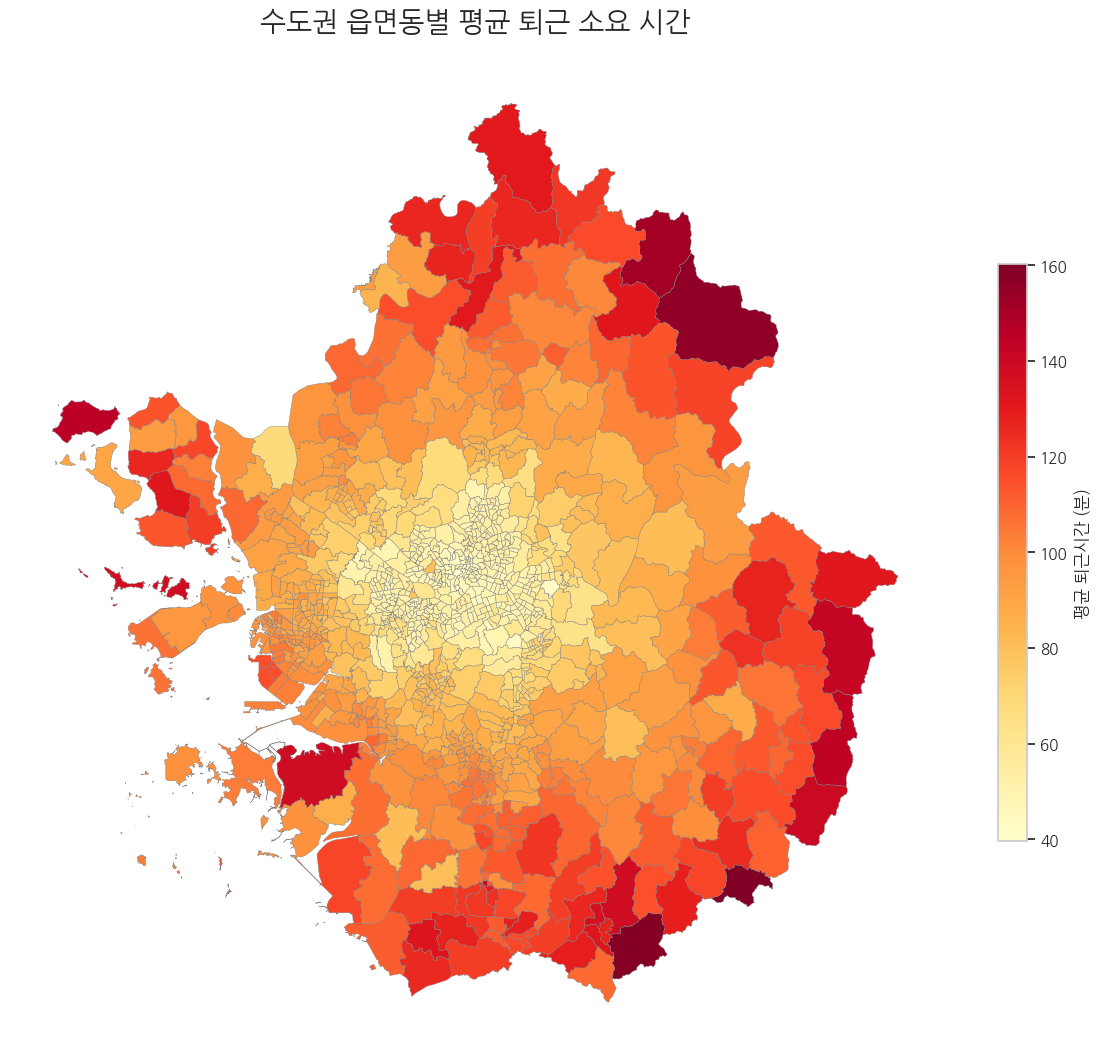

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Shapefile 지도 데이터 불러오기
shp_path = '/content/drive/MyDrive/교통문제공모전/updated_shapefile.shp'
gdf = gpd.read_file(shp_path, encoding='cp949')

# 2. 통근 결과 CSV 데이터 불러오기
commute_path = '/content/drive/MyDrive/교통문제공모전/commute_result_with_avg.csv'
df = pd.read_csv(commute_path, encoding='cp949')

# 'ADM_CD' 컬럼을 문자열로 변환
gdf['ADM_CD'] = gdf['ADM_CD'].astype(str)
# '행정동별 코드' 컬럼의 불필요한 '\r' 문자 제거 및 문자열 변환
# 그리고 gdf의 ADM_CD와 길이를 맞추기 위해 7자리 코드에 '0'을 추가 (예: '1101053' -> '11010530')
df['행정동별 코드'] = df['행정동별 코드'].astype(str).str.replace('\r', '', regex=False)

# 3. 수도권(서울, 인천, 경기) 데이터만 필터링하기 (11: 서울, 23: 인천, 31: 경기)
# 앞 2자리 코드를 추출하여 수도권만 남기기
gdf['sido_code'] = gdf['ADM_CD'].str[:2]
gdf_metro = gdf[gdf['sido_code'].isin(['11', '23', '31'])]

# 4. 지도 데이터(GeoDataFrame)와 통근 데이터(DataFrame) 병합
# 지도 데이터의 읍면동 코드와 CSV의 읍면동 코드를 기준으로 조인
merged_gdf = gdf_metro.merge(df, left_on='ADM_CD', right_on='행정동별 코드', how='inner')

print(f"병합된 GeoDataFrame (merged_gdf)의 행 개수: {len(merged_gdf)}")

# 5. 단계구분도(Choropleth Map) 그리기
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 도화지 크기 설정
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# 시각화 실행
merged_gdf.plot(
    column='평균 퇴근시간',         # 시각화할 통근 데이터의 수치 컬럼명 입력
    ax=ax,
    cmap='YlOrRd',                # 색상 지도 (Yellow-Orange-Red)
    legend=True,
    legend_kwds={'shrink': 0.5, 'label': "평균 퇴근시간 (분)"}, # 범례 설정
    edgecolor='gray',             # 읍면동 경계선 색상
    linewidth=0.3,                # 경계선 두께
    missing_kwds={'color': 'lightgrey',
                  "hatch": "////"} # 데이터가 없는 지역의 색상
)

plt.title('수도권 읍면동별 평균 퇴근 소요 시간', fontsize=20, fontweight='bold', pad=20)
ax.set_axis_off() # 지저분한 X, Y축 좌표선 숨기기

# 결과물 이미지로 저장
plt.savefig('수도권_읍면동별_퇴근시간_지도.png', dpi=300, bbox_inches='tight')
plt.show()

**수도권 읍면동별 출근-퇴근 격차 (출근지옥/퇴근지옥) Top20**

/tmp/ipykernel_1830/512906222.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='출퇴근_시간격차_출근기준', y='행정동명', data=top20_diff_hw,
/tmp/ipykernel_1830/512906222.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='출퇴근_시간격차_퇴근기준', y='행정동명', data=top20_diff_wh,


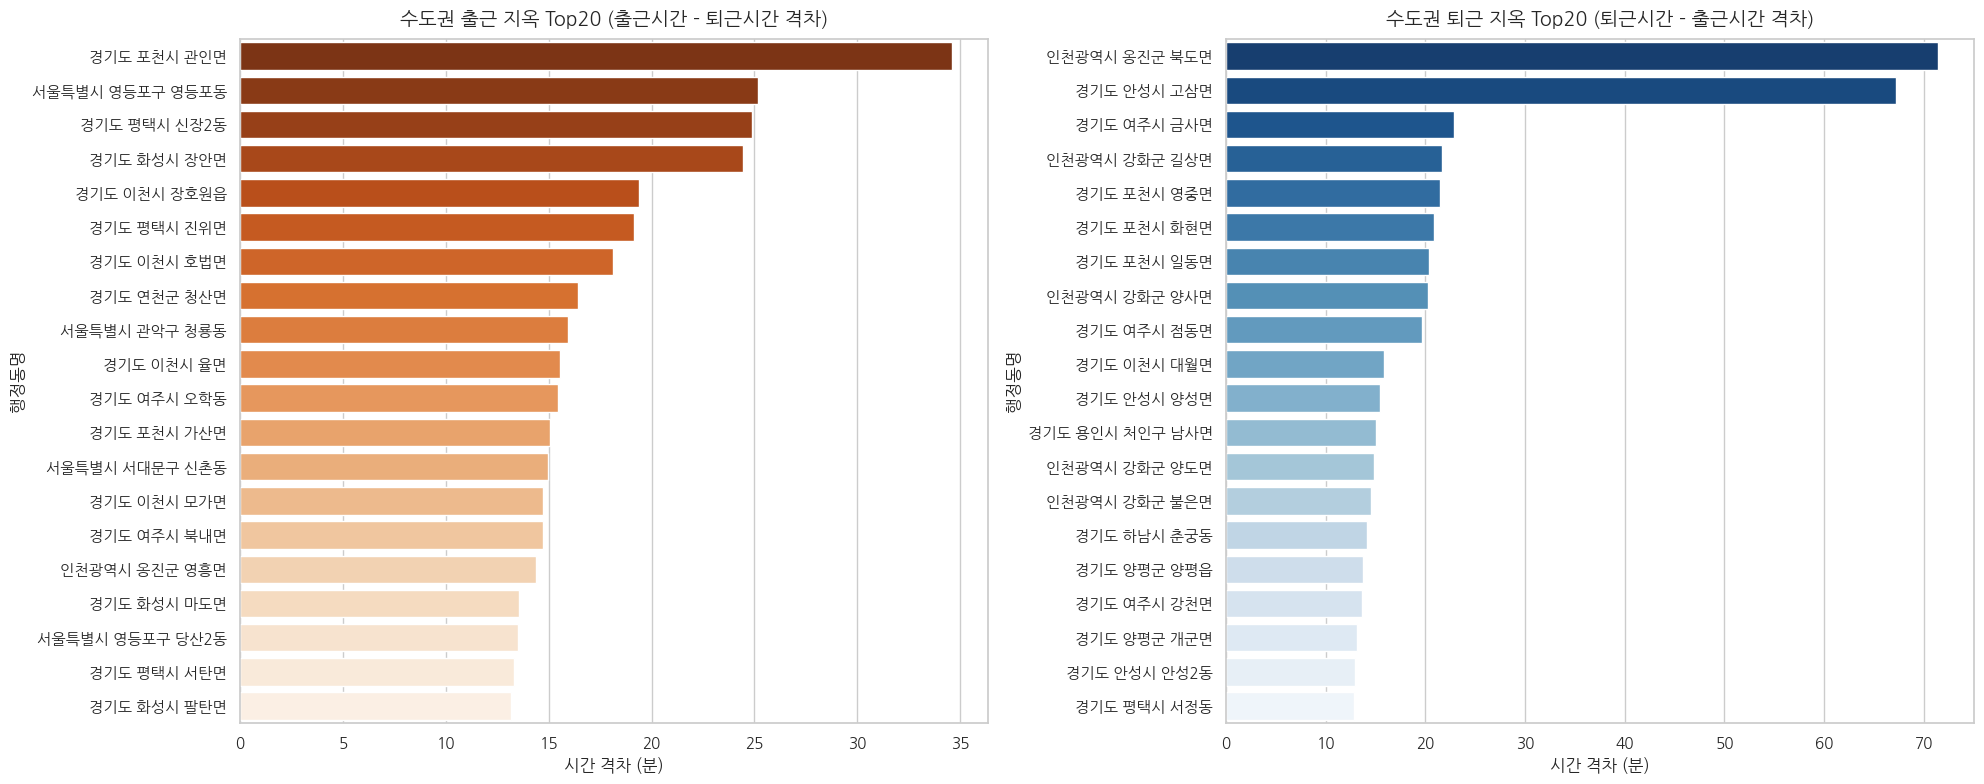

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 시각화를 위한 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'  # 윈도우 사용자
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지

# 2. 통근 결과 CSV 데이터 불러오기
commute_path = '/content/drive/MyDrive/교통문제공모전/commute_result_with_avg.csv'
df_metro = pd.read_csv(commute_path, encoding='cp949')

# 3. 수도권 데이터 필터링 및 격차 인덱스 계산
# 행정동코드를 문자열로 변환하여 앞 2자리 확인
df_metro['행정동별 코드'] = df_metro['행정동별 코드'].astype(str)

# '퇴근 시간 - 출근 시간'을 계산하여 새로운 컬럼 생성
df_metro['출퇴근_시간격차_퇴근기준'] = df_metro['평균 퇴근시간'] - df_metro['평균 출근시간']
df_metro['출퇴근_시간격차_출근기준'] = df_metro['평균 출근시간'] - df_metro['평균 퇴근시간']

# 4. 격차가 큰 상위 20개 지역 추출
# 격차가 양수이고 클수록 퇴근이 출근보다 훨씬 오래 걸리는 곳을 의미함
top20_diff_wh = df_metro.sort_values(by='출퇴근_시간격차_퇴근기준', ascending=False).head(20)
top20_diff_wh = top20_diff_wh.sort_values(by='출퇴근_시간격차_퇴근기준', ascending=False)
top20_diff_hw = df_metro.sort_values(by='출퇴근_시간격차_출근기준', ascending=False).head(20)
top20_diff_hw = top20_diff_hw.sort_values(by='출퇴근_시간격차_출근기준', ascending=False)

#도화지 분할
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

# 첫 번째 그래프 그리기 (왼쪽: axes[0])
sns.barplot(x='출퇴근_시간격차_출근기준', y='행정동명', data=top20_diff_hw,
            ax=axes[0], palette='Oranges_r')
axes[0].set_title('수도권 출근 지옥 Top20 (출근시간 - 퇴근시간 격차)', fontsize=14, pad=10)
axes[0].set_xlabel('시간 격차 (분)')
axes[0].set_ylabel('행정동명')

# 두 번째 그래프 그리기 (오른쪽: axes[1])
sns.barplot(x='출퇴근_시간격차_퇴근기준', y='행정동명', data=top20_diff_wh,
            ax=axes[1], palette='Blues_r')
axes[1].set_title('수도권 퇴근 지옥 Top20 (퇴근시간 - 출근시간 격차)', fontsize=14, pad=10)
axes[1].set_xlabel('시간 격차 (분)')
axes[1].set_ylabel('행정동명')

# 마무리 및 출력
plt.tight_layout()

# 디렉토리가 없으면 생성
output_dir = '수도권 읍면동별 출근지옥'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(f'{output_dir}/퇴근지옥 Top20.png', dpi=300, bbox_inches='tight')
plt.show()

**수도권 읍면동별 평균 출퇴근 소요시간 (출퇴근 = avg(출근,퇴근))**

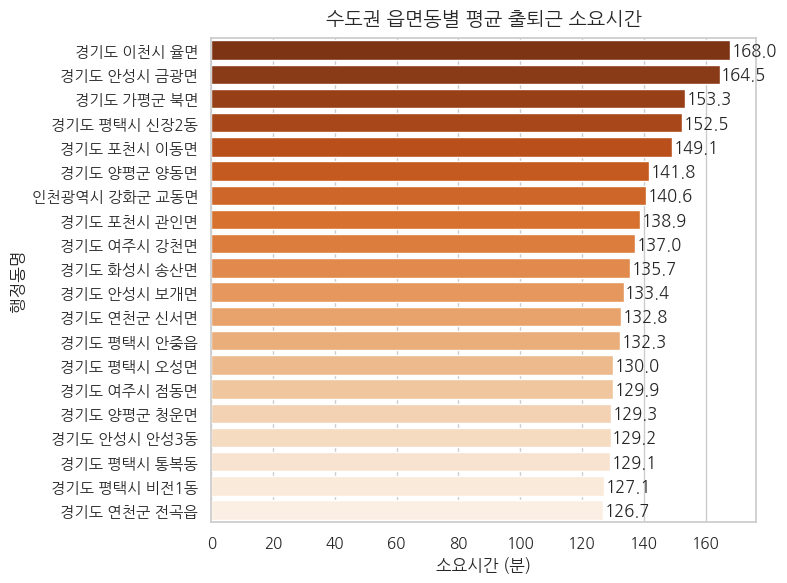

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화를 위한 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'  # 윈도우 사용자
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지

# 2. 통근 결과 CSV 데이터 불러오기
commute_path = '/content/drive/MyDrive/교통문제공모전/commute_result_with_avg.csv'
df_metro = pd.read_csv(commute_path, encoding='cp949')

# 불필요한 부분 제거 및 문자열 변환(읍면동코드)
df_metro['행정동별 코드'] = df_metro['행정동별 코드'].astype(str)
df_metro['행정동명'] = df_metro['행정동명'].str.replace('\r', '', regex=False)

#새로운 컬럼 생성
df_metro['평균 출퇴근시간'] = (df_metro['평균 퇴근시간'] + df_metro['평균 출근시간'])/2

# 4. 격차가 큰 상위 20개 지역 추출
# 격차가 양수이고 클수록 퇴근이 출근보다 훨씬 오래 걸리는 곳을 의미함
top20_commute = df_metro.sort_values(by='평균 출퇴근시간', ascending=False).head(20)

# 플롯을 위해 평균 출퇴근시간을 기준으로 오름차순 정렬하여 가장 긴 막대가 위에 오도록 함
top20_commute_sorted = top20_commute.sort_values(by='평균 출퇴근시간', ascending=False)

# Create a figure and an axes object explicitly for better control
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='평균 출퇴근시간', y='행정동명', data=top20_commute_sorted,
                 palette='Oranges_r', hue='행정동명', legend=False) # FutureWarning 해결

plt.title('수도권 읍면동별 평균 출퇴근 소요시간', fontsize=14, pad=10)
plt.xlabel('소요시간 (분)')
plt.ylabel('행정동명')

# 각 막대 옆에 수치 표시
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.5, p.get_y() + p.get_height() / 2, f'{width:.1f}', va='center')

plt.tight_layout()
plt.savefig('수도권_읍면동별_평균 출퇴근 소요시간.png', dpi=300, bbox_inches='tight')
plt.show()

**수도권 읍면동별 평균 출퇴근 소요시간 지도 매핑 (출퇴근=avg(출근+퇴근))**

병합된 GeoDataFrame (merged_gdf)의 행 개수: 1129


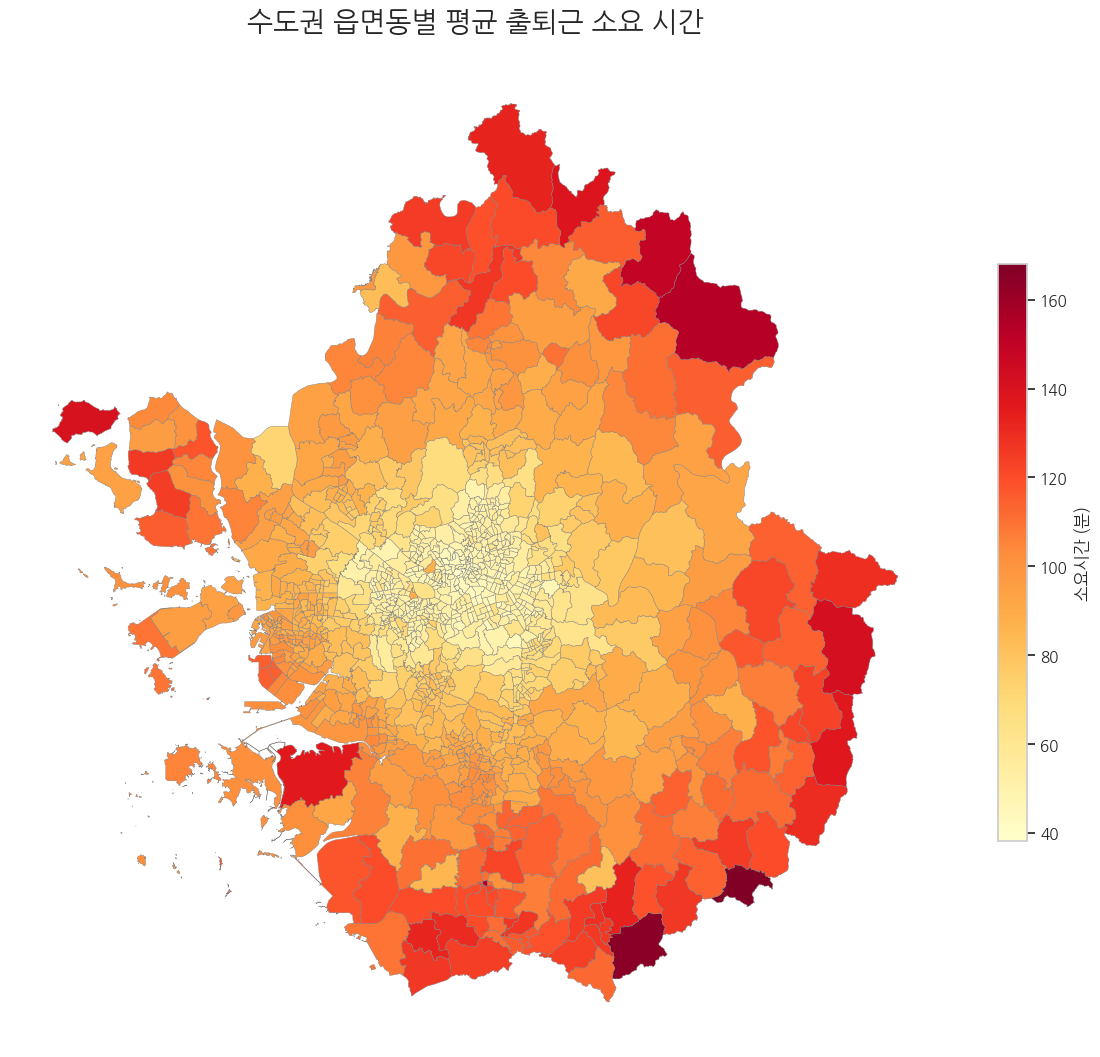

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Shapefile 지도 데이터 불러오기
shp_path = '/content/drive/MyDrive/교통문제공모전/updated_shapefile.shp'
gdf = gpd.read_file(shp_path, encoding='cp949')

# 2. 통근 결과 CSV 데이터 불러오기
commute_path = '/content/drive/MyDrive/교통문제공모전/commute_result_with_avg.csv'
df_metro = pd.read_csv(commute_path, encoding='cp949')

# 'ADM_CD' 컬럼을 문자열로 변환
gdf['ADM_CD'] = gdf['ADM_CD'].astype(str)
# '행정동별 코드' 컬럼의 불필요한 '\r' 문자 제거 및 문자열 변환
# 그리고 gdf의 ADM_CD와 길이를 맞추기 위해 7자리 코드에 '0'을 추가 (예: '1101053' -> '11010530')
df_metro['행정동별 코드'] = df_metro['행정동별 코드'].astype(str).str.replace('\r', '', regex=False)
df_metro['행정동명'] = df_metro['행정동명'].str.replace('\r', '', regex=False)

# 3. 수도권(서울, 인천, 경기) 데이터만 필터링하기 (11: 서울, 23: 인천, 31: 경기)
# 앞 2자리 코드를 추출하여 수도권만 남기기
gdf['sido_code'] = gdf['ADM_CD'].str[:2]
gdf_metro = gdf[gdf['sido_code'].isin(['11', '23', '31'])]

# 4. 지도 데이터(GeoDataFrame)와 통근 데이터(DataFrame) 병합
# 지도 데이터의 읍면동 코드와 CSV의 읍면동 코드를 기준으로 조인
merged_gdf = gdf_metro.merge(df_metro, left_on='ADM_CD', right_on='행정동별 코드', how='inner')

print(f"병합된 GeoDataFrame (merged_gdf)의 행 개수: {len(merged_gdf)}")

# 5. 단계구분도(Choropleth Map) 그리기
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 도화지 크기 설정
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# 시각화 실행
merged_gdf.plot(
    column='평균 출퇴근시간',         # 시각화할 통근 데이터의 수치 컬럼명 입력
    ax=ax,
    cmap='YlOrRd',                # 색상 지도 (Yellow-Orange-Red)
    legend=True,
    legend_kwds={'shrink': 0.5, 'label': "소요시간 (분)"}, # 범례 설정
    edgecolor='gray',             # 읍면동 경계선 색상
    linewidth=0.3,                # 경계선 두께
    missing_kwds={'color': 'lightgrey',
                  "hatch": "////"} # 데이터가 없는 지역의 색상
)

plt.title('수도권 읍면동별 평균 출퇴근 소요 시간', fontsize=20, fontweight='bold', pad=20)
ax.set_axis_off() # 지저분한 X, Y축 좌표선 숨기기

# 결과물 이미지로 저장
plt.savefig('수도권_읍면동별_평균출퇴근시간_지도.png', dpi=300, bbox_inches='tight')
plt.show()

**수도권 시군구별 아파트 중위매매가격**

병합된 GeoDataFrame (merged_gdf)의 행 개수: 1137


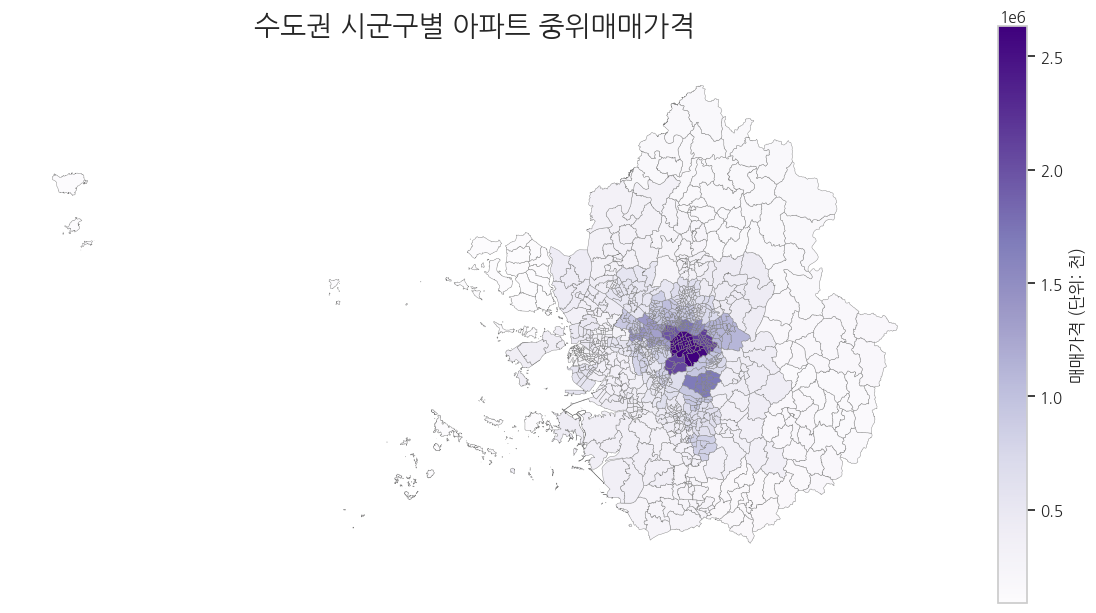

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Shapefile 지도 데이터 불러오기
shp_path = '/content/drive/MyDrive/교통문제공모전/updated_shapefile.shp'
gdf = gpd.read_file(shp_path, encoding='cp949')

# 2. 통근 결과 CSV 데이터 불러오기
apt_path = '/content/drive/MyDrive/교통문제공모전/수도권 시군구 아파트 중위매매가격.csv'
df = pd.read_csv(apt_path, encoding='utf-8')
df["중위매매가"] = (df["중위매매가"].astype(str).str.replace('"', "").str.replace(",", "").str.strip())

# 3. 정수형(int64)으로 타입 변경
df["중위매매가"] = pd.to_numeric(df["중위매매가"], errors='coerce') # Convert to numeric, coercing errors to NaN
df["중위매매가"] = df["중위매매가"].fillna(0).astype(int) # Fill NaN with 0 and then convert to int

df.loc[(df['full_name'].str.contains('인천광역시 강화군')) | (df['full_name'].str.contains('인천광역시 옹진군')), '중위매매가'] = 88750
df.loc[(df['full_name'].str.contains('경기도 가평군')), '중위매매가'] = 158500
df.loc[(df['full_name'].str.contains('경기도 양평군')), '중위매매가'] = 175000
df.loc[(df['full_name'].str.contains('경기도 연천군')), '중위매매가'] = 160000

# 'ADM_CD' 컬럼을 문자열로 변환
gdf['ADM_CD'] = gdf['ADM_CD'].astype(str)
# df의 '읍면동' 컬럼을 '행정동별 코드'로 사용하고, 불필요한 '\r' 문자 제거 및 문자열 변환
df['행정동별 코드'] = df['읍면동'].astype(str).str.replace('\r', '', regex=False)

# 3. 수도권(서울, 인천, 경기) 데이터만 필터링하기 (11: 서울, 23: 인천, 31: 경기)
# 앞 2자리 코드를 추출하여 수도권만 남기기
gdf['sido_code'] = gdf['ADM_CD'].str[:2]
gdf_metro = gdf[gdf['sido_code'].isin(['11', '23', '31'])]

# 4. 지도 데이터(GeoDataFrame)와 통근 데이터(DataFrame) 병합
# 지도 데이터의 읍면동 코드와 CSV의 읍면동 코드를 기준으로 조인
merged_gdf = gdf_metro.merge(df, left_on='ADM_CD', right_on='행정동별 코드', how='inner')

print(f"병합된 GeoDataFrame (merged_gdf)의 행 개수: {len(merged_gdf)}")

# 5. 단계구분도(Choropleth Map) 그리기
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 도화지 크기 설정
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# 시각화 실행
merged_gdf.plot(
    column='중위매매가',         # 시각화할 통근 데이터의 수치 컬럼명 입력
    ax=ax,
    cmap='Purples',                # 색상 지도 (Yellow-Orange-Red)
    legend=True,
    legend_kwds={'shrink': 0.5, 'label': "매매가격 (단위: 천)"}, # 범례 설정
    edgecolor='gray',             # 읍면동 경계선 색상
    linewidth=0.3,                # 경계선 두께
    missing_kwds={'color': 'lightgrey',
                  "hatch": "////"} # 데이터가 없는 지역의 색상
)

plt.title('수도권 시군구별 아파트 중위매매가격', fontsize=20, fontweight='bold', pad=20)
ax.set_axis_off() # 지저분한 X, Y축 좌표선 숨기기

# 결과물 이미지로 저장
plt.savefig('수도권_시군구별_아파트중위매매가격_지도.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

# 1. 두 개의 CSV 파일 불러오기
commute_path = '/content/drive/MyDrive/교통문제공모전/commute_result_with_avg.csv'
df_commute = pd.read_csv(commute_path, encoding='cp949')
apt_path = '/content/drive/MyDrive/교통문제공모전/수도권 시군구 아파트 중위매매가격.csv'
df_apt = pd.read_csv(apt_path, encoding='utf-8')

# 2. 두 데이터프레임 병합 (Join)
merged_df = pd.merge(
    df_commute,
    df_apt,
    left_on='행정동별 코드',
    right_on='읍면동',
    how='inner')

merged_df["중위매매가"] = (merged_df["중위매매가"].astype(str).str.replace('"', "").str.replace(",", "").str.strip())
merged_df['중위매매가'] = pd.to_numeric(merged_df['중위매매가'], errors='coerce').fillna(0).astype(int)
merged_df.head()
merged_df.info()
merged_df.to_csv('final_merged.csv', index=False, encoding='utf-8-sig')
print("'final_merged.csv'로 저장되었습니다")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   행정동별 코드    1128 non-null   int64  
 1   행정동명       1128 non-null   object 
 2   평균 출근시간    1128 non-null   float64
 3   평균 퇴근시간    1128 non-null   float64
 4   평균 출퇴근시간   1128 non-null   float64
 5   시도         1128 non-null   int64  
 6   시군구        1128 non-null   int64  
 7   읍면동        1128 non-null   int64  
 8   name       1128 non-null   object 
 9   full_name  1128 non-null   object 
 10  중위매매가      1128 non-null   int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 97.1+ KB
'final_merged.csv'로 저장되었습니다
